## **Image Classification: Plant Village Datasets**
- Name: Aldi Himawan
- Email: aldihimawan88@gmail.com
- Kaggle link datasets: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

#### **Library import initialization**

In [2]:
# Manipulation data library

import shutil
from shutil import copyfile

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.pyplot import yticks
from matplotlib.pyplot import xticks

import seaborn as sns

from tqdm.notebook import tqdm as tq

In [19]:
# Model building and image processing
import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from keras.layers import InputLayer, Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from keras.models import Sequential

#### **Mounting Datasets**

In [29]:
# dataset_path = "/mnt/d/Personal/experimental/Dicoding/Deep-Learning-Fundamental/plant-leaf-disease-classification/plantvillage dataset/color/"
dataset_path = "/mnt/d/Personal/experimental/Dicoding/Deep-Learning-Fundamental/plant-leaf-disease-classification/plantvillage dataset/segmented/"

split_path = "/mnt/d/Personal/experimental/Dicoding/Deep-Learning-Fundamental/plant-leaf-disease-classification/plantvillage dataset/dataset-split/"

Apple___Apple_scab: 630 images
Apple___Black_rot: 621 images
Apple___Cedar_apple_rust: 275 images
Apple___healthy: 1645 images
Blueberry___healthy: 1502 images
Cherry_(including_sour)___healthy: 854 images
Cherry_(including_sour)___Powdery_mildew: 1052 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Corn_(maize)___Common_rust_: 1192 images
Corn_(maize)___healthy: 1162 images


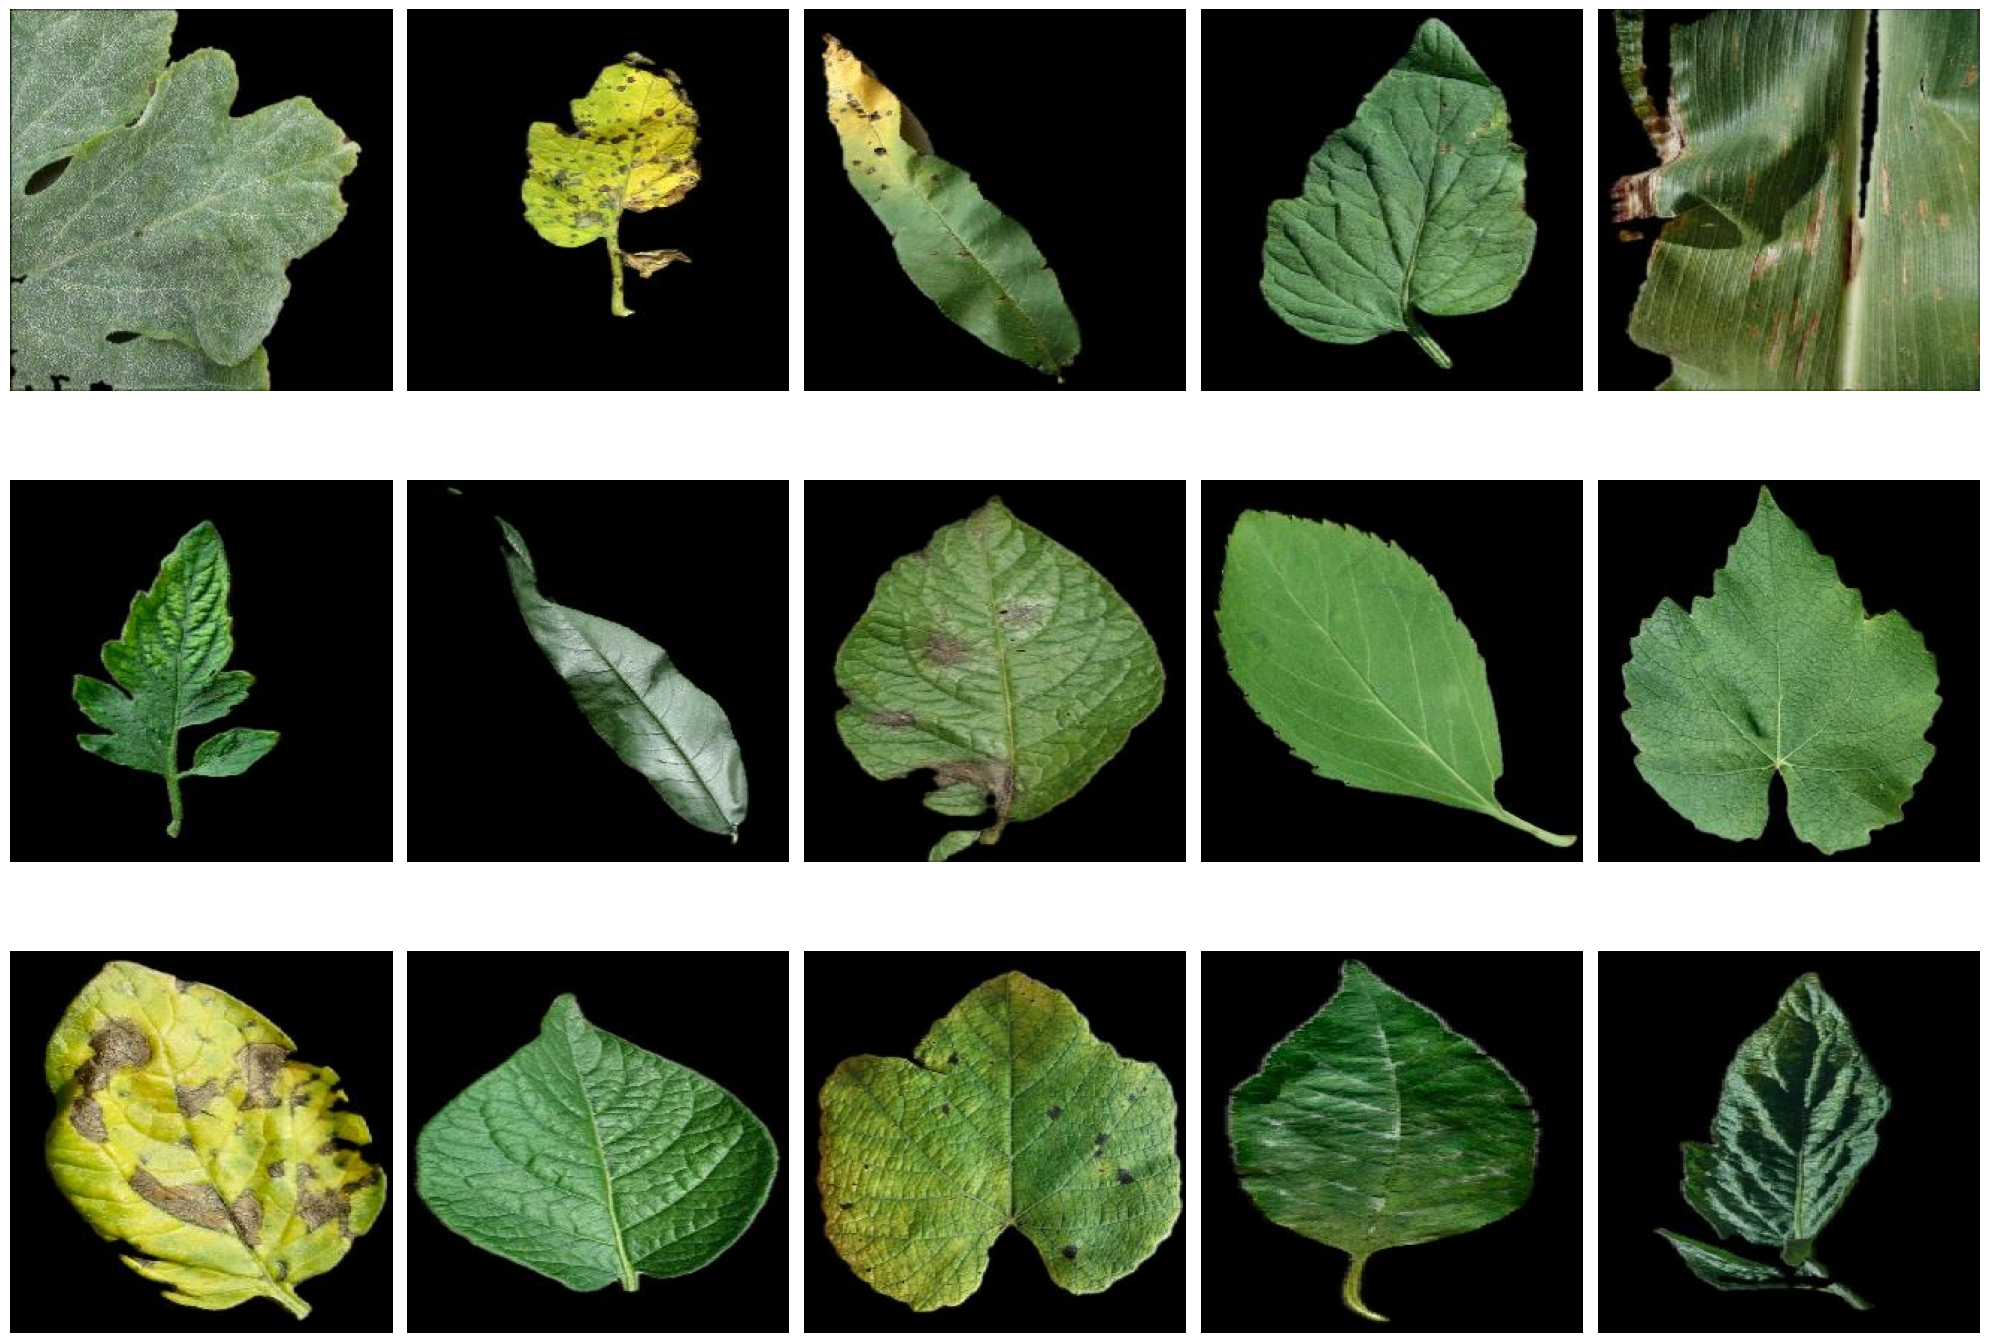

In [14]:
class_names = [
  d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))
]

for class_name in class_names[:10]:
  class_path = os.path.join(dataset_path, class_name)
  num_images = len(os.listdir(class_path))
  print(f"{class_name}: {num_images} images")

fig, axs = plt.subplots(3, 5, figsize=(20, 15))

random_classes = random.sample(class_names, k=3*5)

for i, ax in enumerate(axs.flatten()):
  class_name = random_classes[i]
  class_path = os.path.join(dataset_path, class_name)
  images_in_class = os.listdir(class_path)
  
  random_image_name = random.choice(images_in_class)
  img_path = os.path.join(class_path, random_image_name)
  
  # img = Image.open(img_path).convert('L')
  img = Image.open(img_path)
  ax.imshow(img, cmap='gray')
  ax.axis('off')
  ax.set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()

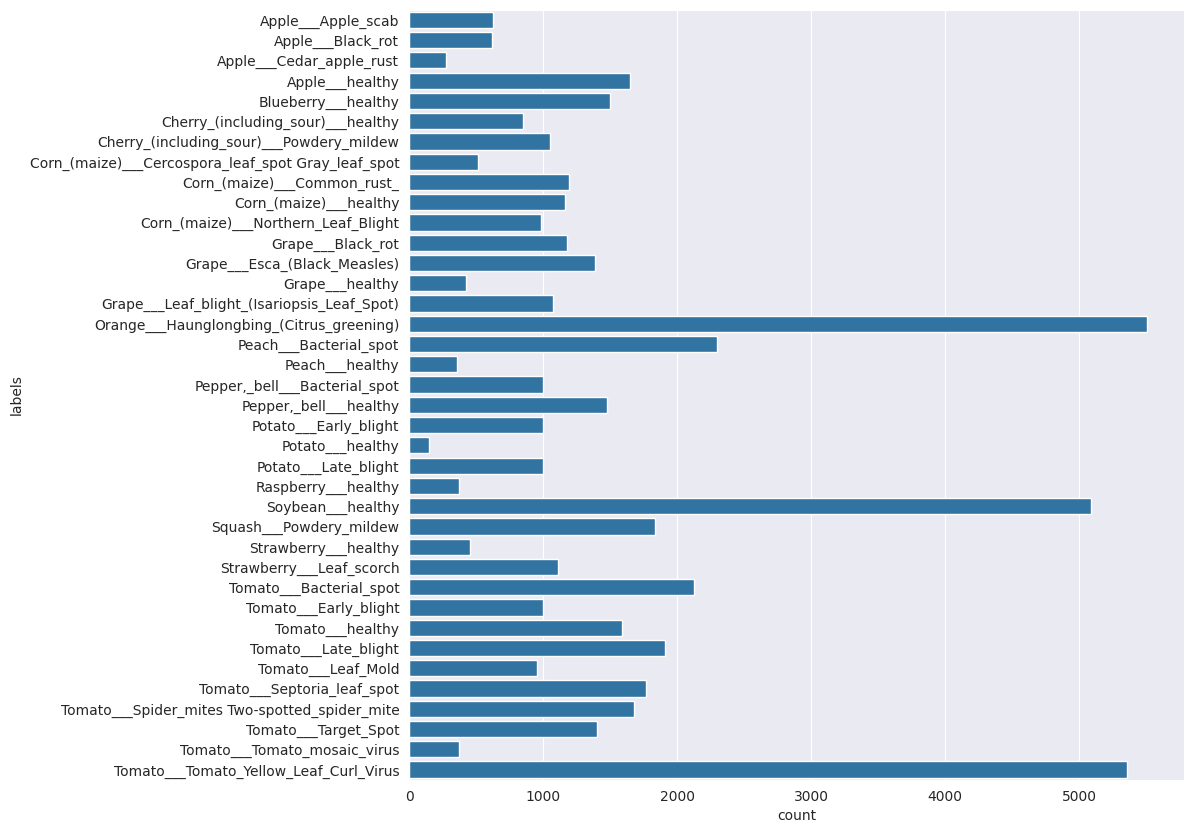

In [15]:
# Distribution Plot

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(dataset_path):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split('/')[-1])
    file_name.append(name)

distribution_train = pd.DataFrame(
  {
    "path": full_path,
    "file_name": file_name,
    "labels": labels
  }
)

label = distribution_train['labels']

plt.figure(figsize=(10, 10))
sns.set_style('darkgrid')
plot_data = sns.countplot(y=label)

#### **Image Augmentation**

In [24]:
def random_augment(img):
  """Apply a random combination of augmentation to a single image"""
  
  h, w = img.shape[:2]
  center = (w // 2, h //2)
  result = img.copy()
  
  def horizontal_flip(img):
    return cv2.flip(img, 1)
  
  def vertical_flip(img):
    return cv2.flip(img, 0)
  
  def rotate_cw(img):
    return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
  
  def rotate_acw(img):
    return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
  
  def rotate_rand(img):
    angle = np.random.uniform(-45, 45)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
  
  def brightness_up(img):
    alpha = np.random.uniform(1.1, 1.4)
    beta = np.random.randint(10, 40)
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
  
  def brightness_down(img):
    alpha = np.random.uniform(0.6, 0.9)
    beta = np.random.randint(-40, -10)
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
  
  def blur(img):
    k = random.choice([3, 5, 7])
    return cv2.GaussianBlur(img, (k, k), 0)
  
  def shear(img):
    h, w = img.shape[:2]
    shear_factor = np.random.uniform(-0.2, 0.2)
    M = np.float32([[1, shear_factor, 0], [0, 1, 0]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
  
  def warp(img):
    h, w = img.shape[:2]
    margin = int(0.1 * min(h, w))
    pts1 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])
    pts2 = np.float32([
      [np.random.randint(0, margin), np.random.randint(0, margin)],
      [w - np.random.randint(0, margin), np.random.randint(0, margin)],
      [np.random.randint(0, margin), h - np.random.randint(0, margin)],
      [w - np.random.randint(0, margin), h - np.random.randint(0, margin)]
    ])
    M = cv2.getPerspectiveTransform(pts1, pts2)
    return cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
  
  def zoom(img):
    h, w = img.shape[:2]
    factor = np.random.uniform(0.1, 0.3)
    crop_h, crop_w = int(h * factor), int(w * factor)
    cropped = img[crop_h:h - crop_h, crop_w:w - crop_w]
    return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)
  
  all_augmentations = [
    horizontal_flip, vertical_flip, rotate_cw, rotate_acw, rotate_rand, brightness_up, brightness_down, blur, shear, warp, zoom
  ]
  
  num_augs = random.randint(1, 3)
  chosen_augs = random.sample(all_augmentations, num_augs)
  
  for aug_fn in chosen_augs:
    result = aug_fn(result)
  
  return result

In [25]:
# RUN THIS JUST FOR THE FIRST TIME

class_counts = {}

for class_name in class_names:
  class_path = os.path.join(dataset_path, class_name)
  class_counts[class_name] = len([
    f for f in os.listdir(class_path)
    
    if os.path.isfile(os.path.join(class_path, f))
  ])
  
max_count = max(class_counts.values())
print(f"Target count per class: {max_count}")

# Augment images
for class_name, count, in tq(class_counts.items(), desc="Balancing Classes"):
  if count < max_count:
    class_path = os.path.join(dataset_path, class_name)
    images = [
      f for f in os.listdir(class_path)
      if os.path.isfile(os.path.join(class_path, f))
    ]
    needed = max_count - count
    
    for i in range(needed):
      img_name = random.choice(images)
      img_path = os.path.join(class_path, img_name)
      img = cv2.imread(img_path)
      
      if img is None:
        continue
      
      aug_img = random_augment(img)
      
      save_name = f"aug_{i}_{img_name}"
      cv2.imwrite(os.path.join(class_path, save_name), aug_img)

  print(f"{class_name}: {count} -> {max_count} images")

Target count per class: 5507


Balancing Classes:   0%|          | 0/38 [00:00<?, ?it/s]

Apple___Apple_scab: 630 -> 5507 images
Apple___Black_rot: 621 -> 5507 images
Apple___Cedar_apple_rust: 275 -> 5507 images
Apple___healthy: 1645 -> 5507 images
Blueberry___healthy: 1502 -> 5507 images
Cherry_(including_sour)___healthy: 854 -> 5507 images
Cherry_(including_sour)___Powdery_mildew: 1052 -> 5507 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 -> 5507 images
Corn_(maize)___Common_rust_: 1192 -> 5507 images
Corn_(maize)___healthy: 1162 -> 5507 images
Corn_(maize)___Northern_Leaf_Blight: 985 -> 5507 images
Grape___Black_rot: 1180 -> 5507 images
Grape___Esca_(Black_Measles): 1384 -> 5507 images
Grape___healthy: 423 -> 5507 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 -> 5507 images
Orange___Haunglongbing_(Citrus_greening): 5507 -> 5507 images
Peach___Bacterial_spot: 2297 -> 5507 images
Peach___healthy: 360 -> 5507 images
Pepper,_bell___Bacterial_spot: 997 -> 5507 images
Pepper,_bell___healthy: 1478 -> 5507 images
Potato___Early_blight: 1000 -> 5507 ima

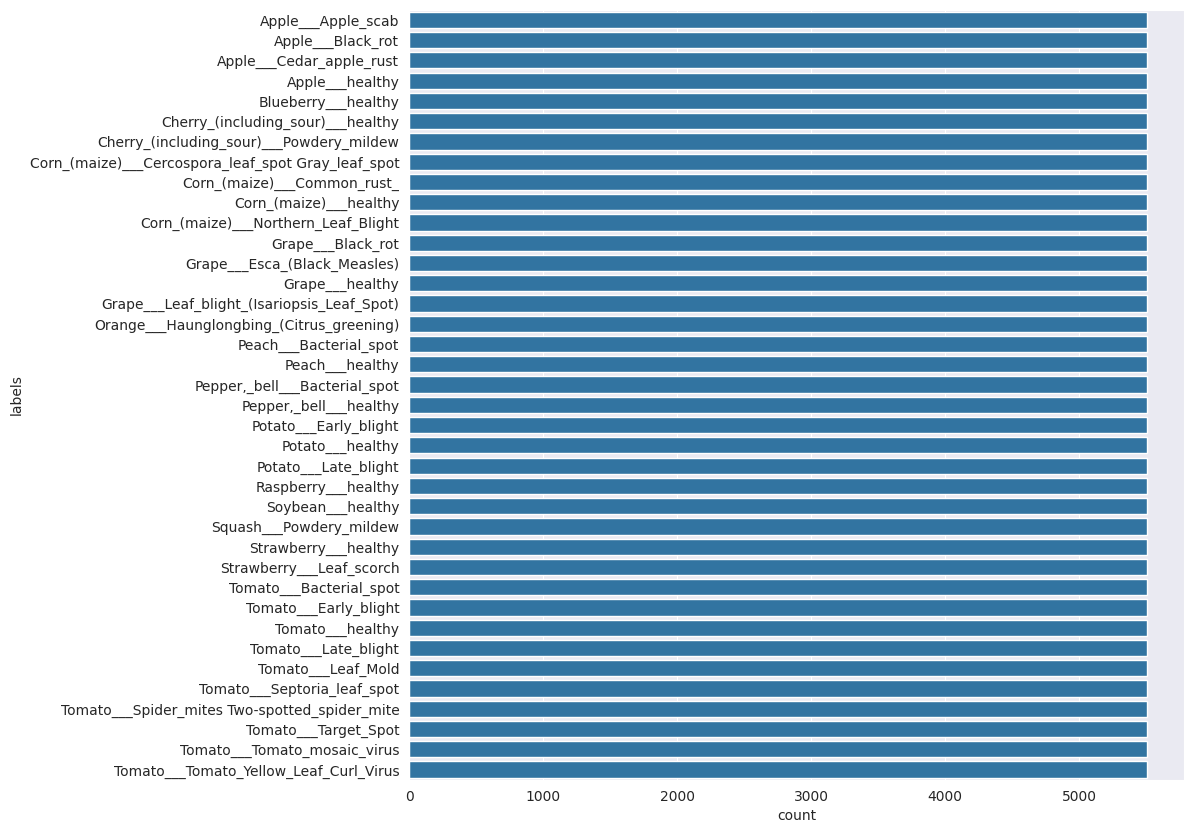

In [26]:
# Distribution Plot

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(dataset_path):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split('/')[-1])
    file_name.append(name)

distribution_train = pd.DataFrame(
  {
    "path": full_path,
    "file_name": file_name,
    "labels": labels
  }
)

label = distribution_train['labels']

plt.figure(figsize=(10, 10))
sns.set_style('darkgrid')
plot_data = sns.countplot(y=label)

#### **Split Dataset**

In [ ]:
for class_name in tq(class_names, desc="Splitting dataset"):
  class_dir = os.path.join(dataset_path, class_name)
  
  images = [
    f for f in os.listdir(class_dir)
    if os.path.isfile(os.path.join(class_dir, f))
  ]
  
  # Split into Train and Test Datasets with ratio 70:30
  train_imgs, test_imgs = train_test_split(
    images, test_size=0.3, random_state=42, shuffle=True
  )
  
  # Split into Train and Validation Datasets from train_imgs with ratio 80:20
  train_imgs, val_imgs = train_test_split(
    train_imgs, test_size=0.2, random_state=42, shuffle=True
  )
  
  splits = {
    'train': train_imgs,
    'validation': val_imgs,
    'test': test_imgs
  }
  
  for split_name, split_images in splits.items():
    dest_dir = os.path.join(split_path, split_name, class_name)
    os.makedirs(dest_dir, exist_ok=True)
    
    for img_name in split_images:
      src = os.path.join(class_dir, img_name)
      dst = os.path.join(dest_dir, img_name)
      shutil.copy2(src, dst)

Splitting dataset:   0%|          | 0/38 [00:00<?, ?it/s]

In [ ]:
for split_name in ['train', 'validation', 'test']:
  split_dir = os.path.join(split_path, split_name)
  total = 0
  
  for class_name in sorted(os.listdir(split_dir)):
    class_dir = os.path.join(split_dir, class_name)
    count = len(os.listdir(class_dir))
    total += count
    
    print(f"  {class_name}: {count} images")
  
  print(f"  TOTAL: {total} images")